### 0 (No Churn): They have not left.
### 1 (Churn): They have actively left.


In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [200]:
df = pd.read_csv("C:\\Users\\edwin\\OneDrive\\Desktop\\development_journey\\20.Machine Learning\\customer_churn_Kaggle\\telecom_churn.csv")

In [201]:
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [202]:
df.drop(columns=["ContractRenewal"],axis=0,inplace=True)

In [203]:
df.shape

(3333, 10)

In [204]:
df.columns

Index(['Churn', 'AccountWeeks', 'DataPlan', 'DataUsage', 'CustServCalls',
       'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee', 'RoamMins'],
      dtype='object')

In [205]:
df.dtypes

Churn              int64
AccountWeeks       int64
DataPlan           int64
DataUsage        float64
CustServCalls      int64
DayMins          float64
DayCalls           int64
MonthlyCharge    float64
OverageFee       float64
RoamMins         float64
dtype: object

In [206]:
df["Churn"].value_counts()

Churn
0    2850
1     483
Name: count, dtype: int64

In [207]:
df.isnull().sum()

Churn            0
AccountWeeks     0
DataPlan         0
DataUsage        0
CustServCalls    0
DayMins          0
DayCalls         0
MonthlyCharge    0
OverageFee       0
RoamMins         0
dtype: int64

In [208]:
df[df.duplicated()]

,Churn,AccountWeeks,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins


In [209]:
X = df.iloc[:,1:]
Y = df.iloc[:,0]

In [210]:
X.head()

,AccountWeeks,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,128,1,2.7,1,265.1,110,89.0,9.87,10.0
1,107,1,3.7,1,161.6,123,82.0,9.78,13.7
2,137,0,0.0,0,243.4,114,52.0,6.06,12.2
3,84,0,0.0,2,299.4,71,57.0,3.10,6.6
4,75,0,0.0,3,166.7,113,41.0,7.42,10.1


In [211]:
Y.head()

0    0
1    0
2    0
3    0
4    0
Name: Churn, dtype: int64

In [212]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [213]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [214]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,Y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [215]:
Y_pred = knn.predict(X_test)

In [216]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

print("===== KNN =====")

print("accuracy score",accuracy_score(Y_pred,Y_test)*100)
print("precision_score",precision_score(Y_pred,Y_test)*100)
print("recall_score",recall_score(Y_pred,Y_test)*100)
print("f1_score",f1_score(Y_pred,Y_test)*100)

===== KNN =====
accuracy score 91.1544227886057
precision_score 44.554455445544555
recall_score 93.75
f1_score 60.40268456375839


In [217]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train,Y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [218]:
Y_predict = nb.predict(X_test)

In [219]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

print("===== naive bayes =====")


print("accuracy score",accuracy_score(Y_predict,Y_test)*100)
print("precision_score",precision_score(Y_predict,Y_test)*100)
print("recall_score",recall_score(Y_predict,Y_test)*100)
print("f1_score",f1_score(Y_predict,Y_test)*100)

===== naive bayes =====
accuracy score 86.50674662668666
precision_score 19.801980198019802
recall_score 68.96551724137932
f1_score 30.76923076923077


In [220]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion="entropy",max_depth=4)
dt.fit(X_train,Y_train)
Y_predict1 = dt.predict(X_test)

In [221]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

print("===== decision tree =====")

print("accuracy score",accuracy_score(Y_predict1,Y_test)*100)
print("precision_score",precision_score(Y_predict1,Y_test)*100)
print("recall_score",recall_score(Y_predict1,Y_test)*100)
print("f1_score",f1_score(Y_predict1,Y_test)*100)

===== decision tree =====
accuracy score 90.70464767616193
precision_score 48.51485148514851
recall_score 83.05084745762711
f1_score 61.25000000000001


In [222]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [223]:
Y_predict2 = rf.predict(X_test)

In [224]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

print("===== Random Forest =====")

print("accuracy score",accuracy_score(Y_predict2,Y_test)*100)
print("precision_score",precision_score(Y_predict2,Y_test)*100)
print("recall_score",recall_score(Y_predict2,Y_test)*100)
print("f1_score",f1_score(Y_predict2,Y_test)*100)

===== Random Forest =====
accuracy score 91.904047976012
precision_score 54.45544554455446
recall_score 87.3015873015873
f1_score 67.07317073170732


In [225]:
user_input = [[65,1,0.29,4,129.1,137,44.9,11.43,12.7]]

dt.predict(scaler.transform(user_input))

C:\Users\edwin\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([1])

In [226]:
from sklearn.ensemble import AdaBoostClassifier
ab = AdaBoostClassifier()
ab.fit(X_train,Y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [227]:
Y_predict3 = ab.predict(X_test)

In [228]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

print("===== ADA BOOST =====")

print("accuracy score",accuracy_score(Y_predict3,Y_test)*100)
print("precision_score",precision_score(Y_predict3,Y_test)*100)
print("recall_score",recall_score(Y_predict3,Y_test)*100)
print("f1_score",f1_score(Y_predict3,Y_test)*100)

===== ADA BOOST =====
accuracy score 89.20539730134932
precision_score 36.633663366336634
recall_score 82.22222222222221
f1_score 50.68493150684932


In [229]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(X_train,Y_train)
Y_predict4 = gb.predict(X_test)

In [230]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

print("===== GRADIENT BOOST =====")

print("accuracy score",accuracy_score(Y_predict4,Y_test)*100)
print("precision_score",precision_score(Y_predict4,Y_test)*100)
print("recall_score",recall_score(Y_predict4,Y_test)*100)
print("f1_score",f1_score(Y_predict4,Y_test)*100)

===== GRADIENT BOOST =====
accuracy score 91.60419790104947
precision_score 52.475247524752476
recall_score 86.88524590163934
f1_score 65.4320987654321


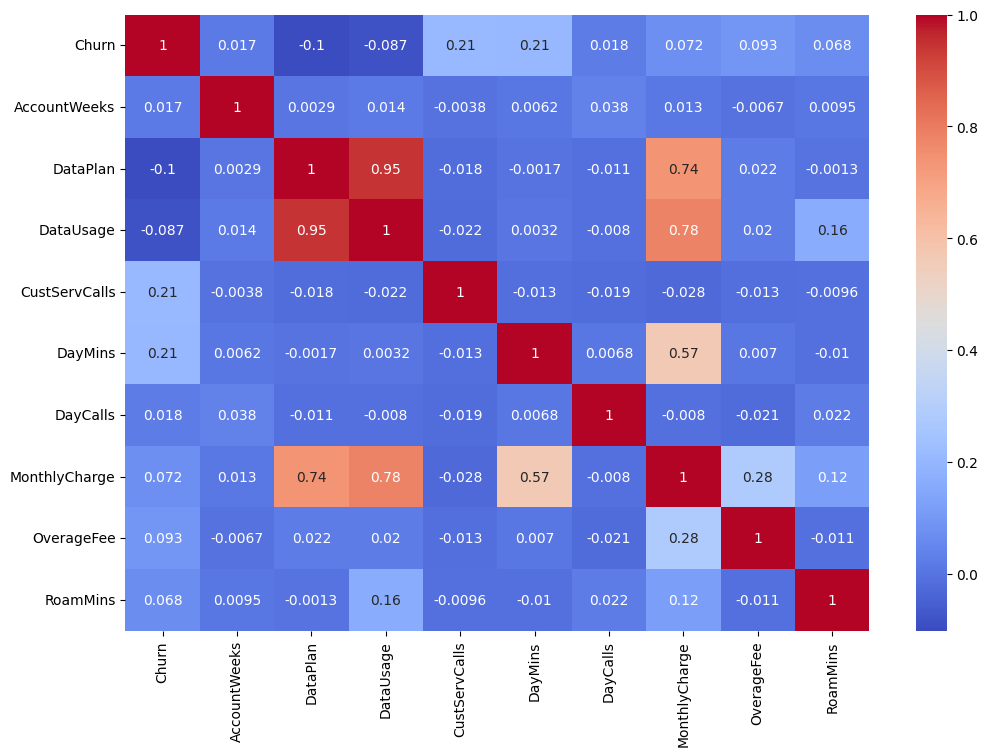

In [231]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [232]:
!pip list

Package                      Version
---------------------------- -----------
absl-py                      2.3.1
altair                       6.0.0
annotated-types              0.7.0
anyio                        4.10.0
app                          0.0.1
arabic-reshaper              3.0.0
asgiref                      3.9.1
asn1crypto                   1.5.1
asttokens                    3.0.1
attrs                        26.1.0
beautifulsoup4               4.14.2
blinker                      1.9.0
cachetools                   6.2.1
certifi                      2025.8.3
cffi                         2.0.0
charset-normalizer           3.4.3
click                        8.2.1
colorama                     0.4.6
comm                         0.2.3
contourpy                    1.3.3
crispy-bootstrap4            2025.6
crispy-bootstrap5            2024.10
cryptography                 46.0.3
cssselect2                   0.8.0
cycler                       0.12.1
debugpy                      1.8.20


In [233]:
from xgboost import XGBClassifier
xg = XGBClassifier()
xg.fit(X_train,Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [234]:
Y_predict5 = xg.predict(X_test)

In [235]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

print("===== XG BOOST =====")

print("accuracy score",accuracy_score(Y_predict5,Y_test)*100)
print("precision_score",precision_score(Y_predict5,Y_test)*100)
print("recall_score",recall_score(Y_predict5,Y_test)*100)
print("f1_score",f1_score(Y_predict5,Y_test)*100)

===== XG BOOST =====
accuracy score 90.55472263868066
precision_score 53.46534653465347
recall_score 77.14285714285715
f1_score 63.1578947368421
